In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import io
from IPython.display import display
import ipywidgets as widgets



# Analysise  And  Reporting


 1.1 Analysis On Given_data
   1.1.1 on User inserted_Data
   1.1.2 On Given cvs file data
   1.1.3 On web_linked cvs data



1.2 Reporting On Given Data
  1.2.1 Reporting On User Inserted_Data
  1.2.2 Reporting On Given Cvs file Data
  1.2.3 Reporting On Web_Linked cvs Data








================ Welcome ===================
Enter Your Choice
1. Enter CSV Data by Path
2. Upload CSV File
3. Enter CSV Data From Link
         Name Gender  Maths  Physics  Chemistry  English  Biology  Economics  \
0    Student1      M     78       65         89       76       88         67   
1    Student2      F     56       74         68       85       79         80   
2    Student3      M     90       88         92       84       86         75   
3    Student4      F     45       55         60       50       58         62   
4    Student5      M     67       70         72       68       74         71   
5    Student6      F     88       92         85       90       91         87   
6    Student7      M     34       40         38       45       42         39   
7    Student8      F     76       82         79       85       80         78   
8    Student9      M     59       61         63       65       67         60   
9   Student10      F     92       94         91       89       9

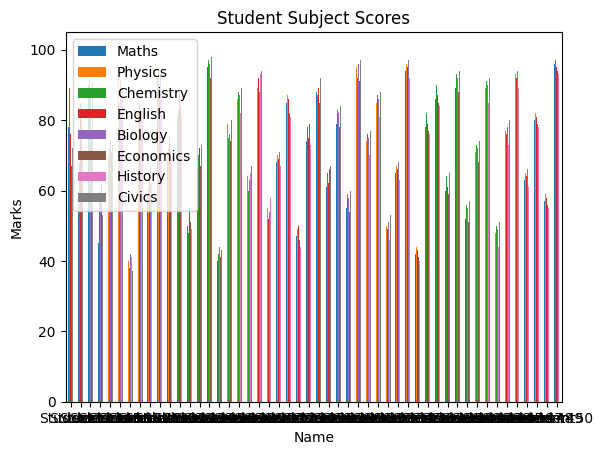

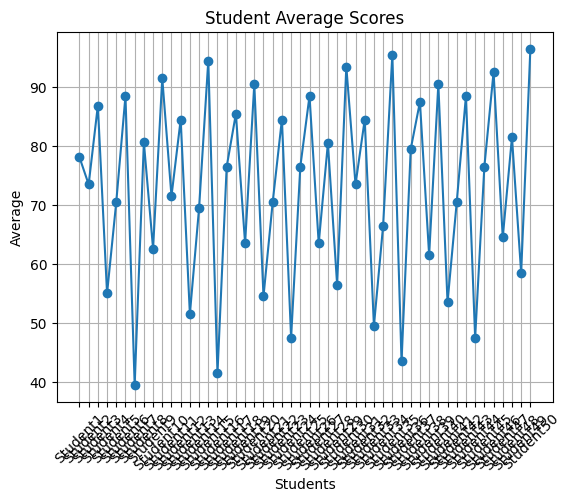

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import io

print("============================================")
print("================ Welcome ===================")
print("============================================")
print("Enter Your Choice")
print("1. Enter CSV Data by Path")
print("2. Upload CSV File")
print("3. Enter CSV Data From Link")

upload = widgets.FileUpload()

# ===============================
# 1. Data insertion             =
# ===============================
def Data_Insertion(choice):
    if choice == 1:
        path = input("Enter CSV file path: ")
        df = pd.read_csv(path)
        print(df)
        return df

    elif choice == 2:
        display(upload)
        print("Upload file, then run again to process it.")

        if upload.value:
            uploaded_filename = list(upload.value.keys())[0]
            content = upload.value[uploaded_filename]['content']
            df = pd.read_csv(io.BytesIO(content))
            print(df)
            return df
        else:
            return None

    elif choice == 3:
        url = input("Enter CSV file URL: ")
        df = pd.read_csv(url)
        print(df)
        return df

    else:
        print("Invalid choice.")
        return None


# ===============================
# 2. Data oprations/ calculation
# ===============================
def Data_Calculation(df):

    # Automatically detect numeric columns (subjects)
    subjects = df.select_dtypes(include="number").columns

    df["Average"] = df[subjects].mean(axis=1)
    df["Max Score"] = df[subjects].max(axis=1)
    df["Result"] = df["Average"].apply(lambda x: "Pass" if x >= 50 else "Fail")

    print("\n===== CALCULATED DATA =====\n")
    print(df)

    return df


# ===============================
# 3. Data visualization         =
# ===============================
def Data_Visualization(df):

  
    subjects = df.select_dtypes(include="number").columns

    # Remove calculated columns from graph
    subjects = [col for col in subjects if col not in ["Average", "Max Score"]]

    # ===== Ploting The Bar Chart =====
    df.set_index(df.columns[0])[subjects].plot(kind="bar")

    plt.title("Student Subject Scores")
    plt.ylabel("Marks")
    plt.xticks(rotation=0)
    plt.show()

    # ===== Average Line Graph =====
    plt.plot(df[df.columns[0]], df["Average"], marker="o")

    plt.title("Student Average Scores")
    plt.xlabel("Students")
    plt.ylabel("Average")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()


# ===============================
#      Main Function Callings   =
# ===============================
try:
    x = int(input("Enter Your Choice: "))

    df = Data_Insertion(x)

    if df is not None:
        df = Data_Calculation(df)
        Data_Visualization(df)
    else:
        print("No data to process.")

except Exception as e:
    print(f"Error: {e}")